# Supplier scorecard: the numbers

This notebook computes every number in the README and on the scorecard, straight from the input files in `data/input/`.
It does not read the warehouse, so it is an independent check: `powerbi/06-checks.md` compares its numbers with
the SQL in `sql/check_numbers.sql` and with the Power BI report.

Every client value (the name, the input files, the rule thresholds, the summary week, the chart window, the colours)
comes from `config/client.yaml` through `load_config()`.

**The rules** (the same ones the DAX measures use; the grace values are `rules.*` in `config/client.yaml`):

| Term | Rule |
|---|---|
| Order line | One item of one order, sold by one supplier |
| Delivered (in full) | The line has a delivery date |
| On time | Delivered on or before the promised date plus `on_time_grace_days` |
| Late | Delivered after that |
| Late hand-over | The carrier got it more than `handover_grace_hours` after the supplier's deadline |
| OTIF | On time and in full: on-time lines ÷ all order lines |
| Fill rate | Delivered lines ÷ all order lines |
| Late rate | Late lines ÷ delivered lines |
| Days late | Days between the promised date and the delivery, for late lines |

In [1]:
import sys

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

sys.path.append("..")
from config import load_config

cfg = load_config()
NAME = cfg["client"]["name"]
IN, FILES, RULES = cfg["input_dir"], cfg["inputs"], cfg["rules"]
COLOURS = cfg["report"]["colours"]
# Charts use the README's navy and teal look; the Power BI theme keeps client.yaml's colours.
COLOURS = {**COLOURS, "data": ["#2DD4BF", "#E2E8F0", "#A78BFA", "#94A3B8", "#14B8A6", "#475569"],
           "text": "#E2E8F0", "muted": "#94A3B8", "line": "#334155"}
ACCENT, OTHER, INK, LINE = COLOURS["data"][0], COLOURS["data"][5], COLOURS["text"], COLOURS["line"]
DOCS = "../docs"
plt.rcParams.update({"font.family": "Segoe UI", "font.size": 11, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.edgecolor": LINE, "axes.labelcolor": INK, "xtick.color": INK, "ytick.color": INK,
                     "text.color": INK, "figure.facecolor": "#0F172A", "axes.facecolor": "#0F172A", "savefig.facecolor": "#0F172A"})

orders = pd.read_csv(IN / FILES["orders"], encoding="utf-8-sig",
                     parse_dates=["order_purchase_timestamp", "order_delivered_carrier_date",
                                  "order_delivered_customer_date", "order_estimated_delivery_date"])
items = pd.read_csv(IN / FILES["order_items"], encoding="utf-8-sig", parse_dates=["shipping_limit_date"])
products = pd.read_csv(IN / FILES["products"], encoding="utf-8-sig")
sellers = pd.read_csv(IN / FILES["sellers"], encoding="utf-8-sig")
categories = pd.read_csv(IN / FILES["categories"], encoding="utf-8-sig")
print(f"{NAME}: {len(orders):,} orders, {len(items):,} order lines, {len(sellers):,} suppliers, {len(products):,} products")
print("rules:", RULES)

Sample marketplace: 99,441 orders, 112,650 order lines, 3,095 suppliers, 32,951 products
rules: {'on_time_grace_days': 0, 'handover_grace_hours': 0, 'watch_list_min_lines': 30, 'watch_list_times_overall': 2}


## One table of order lines
The same join as `sql/02_star.sql`: each line gets its order's dates, its supplier code and its department.

In [2]:
sellers = sellers.sort_values("seller_id").reset_index(drop=True)
sellers["supplier"] = "S" + (sellers.index + 1).astype(str).str.zfill(4)

lines = (items.merge(orders, on="order_id")
              .merge(sellers[["seller_id", "supplier"]], on="seller_id")
              .merge(products[["product_id", "product_category_name"]], on="product_id")
              .merge(categories[["product_category_name", "department"]], on="product_category_name", how="left"))
lines["department"] = lines["department"].fillna("Other")

due = lines["order_estimated_delivery_date"].dt.normalize()
delivered_day = lines["order_delivered_customer_date"].dt.normalize()
on_time_by = due + pd.Timedelta(days=RULES["on_time_grace_days"])
lines["delivered"] = lines["order_delivered_customer_date"].notna()
lines["on_time"] = lines["delivered"] & (delivered_day <= on_time_by)
lines["late"] = lines["delivered"] & (delivered_day > on_time_by)
lines["days_late"] = (delivered_day - due).dt.days
lines["handed"] = lines["order_delivered_carrier_date"].notna()
handover_by = lines["shipping_limit_date"] + pd.Timedelta(hours=RULES["handover_grace_hours"])
lines["late_handover"] = lines["handed"] & (lines["order_delivered_carrier_date"] > handover_by)
lines["due_week"] = due.dt.to_period("W-SUN").dt.start_time
lines["due_month"] = due.dt.to_period("M")
print(f"{len(lines):,} order lines")

112,650 order lines


## The headline numbers

In [3]:
def scorecard(g):
    return pd.Series({
        "orders": g["order_id"].nunique(),
        "order_lines": len(g),
        "delivered_lines": g["delivered"].sum(),
        "late_lines": g["late"].sum(),
        "late_rate_pct": round(100 * g["late"].sum() / g["delivered"].sum(), 2),
        "fill_rate_pct": round(100 * g["delivered"].sum() / len(g), 2),
        "otif_pct": round(100 * g["on_time"].sum() / len(g), 2),
        "avg_days_late": round(g.loc[g["late"], "days_late"].mean(), 2),
        "late_handover_lines": g["late_handover"].sum(),
        "late_handover_rate_pct": round(100 * g["late_handover"].sum() / g["handed"].sum(), 2),
        "late_after_late_handover_pct": round(100 * (g["late"] & g["late_handover"]).sum() / g["late"].sum(), 2),
    })

overall = scorecard(lines)
overall

orders                           98666.00
order_lines                     112650.00
delivered_lines                 110196.00
late_lines                        7265.00
late_rate_pct                        6.59
fill_rate_pct                       97.82
otif_pct                            91.37
avg_days_late                       10.49
late_handover_lines              10423.00
late_handover_rate_pct               9.35
late_after_late_handover_pct        29.02
dtype: float64

## By department
Each buyer owns one department (`inputs.buyers`); in Power BI each buyer sees only their row.

In [4]:
by_department = lines.groupby("department").apply(scorecard, include_groups=False)
by_department

,orders,order_lines,delivered_lines,late_lines,late_rate_pct,fill_rate_pct,otif_pct,avg_days_late,late_handover_lines,late_handover_rate_pct,late_after_late_handover_pct
department,,,,,,,,,,,
"Books, Media & Stationery",3872.0,4193.0,4086.0,277.0,6.78,97.45,90.84,10.75,405.0,9.80,31.77
Electronics,15383.0,17271.0,16868.0,1146.0,6.79,97.67,91.03,9.77,1725.0,10.12,31.15
"Food, Drink & Pets",2683.0,3114.0,3053.0,157.0,5.14,98.04,93.00,10.21,306.0,9.92,36.31
Health & Beauty,12013.0,13128.0,12846.0,934.0,7.27,97.85,90.74,9.98,1099.0,8.44,29.76
Home & Furniture,18221.0,22535.0,22149.0,1580.0,7.13,98.29,91.28,10.87,2535.0,11.33,32.15
Kitchen & Appliances,7866.0,9054.0,8828.0,434.0,4.92,97.50,92.71,10.61,841.0,9.41,32.72
Other,1731.0,1914.0,1842.0,126.0,6.84,96.24,89.66,11.01,255.0,13.61,42.86
Sports & Fashion,16780.0,18366.0,17941.0,1138.0,6.34,97.69,91.49,10.14,1329.0,7.32,20.04
"Tools, Garden & Auto",9890.0,11635.0,11407.0,742.0,6.50,98.04,91.66,11.15,940.0,8.16,23.58


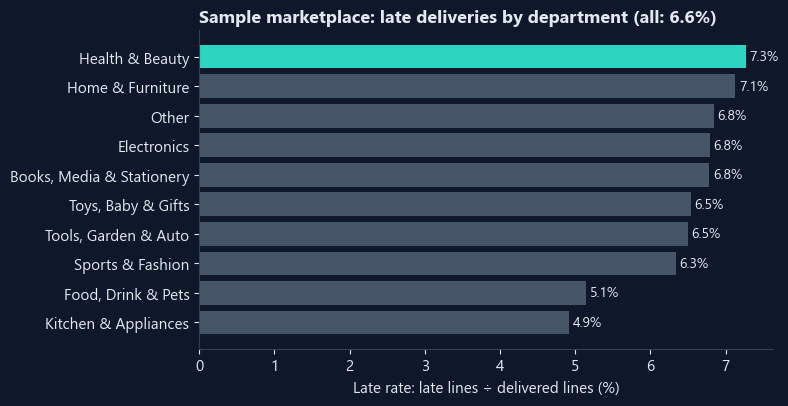

In [5]:
d = by_department.dropna(subset=["late_rate_pct"]).sort_values("late_rate_pct")  # a department with no delivered line has no late rate
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.barh(d.index, d["late_rate_pct"], color=[ACCENT if v == d["late_rate_pct"].max() else OTHER for v in d["late_rate_pct"]])
for y, v in enumerate(d["late_rate_pct"]):
    ax.text(v + 0.05, y, f"{v:.1f}%", va="center", fontsize=10, color=INK)
ax.set_xlabel("Late rate: late lines ÷ delivered lines (%)")
ax.set_title(f"{NAME}: late deliveries by department (all: {overall['late_rate_pct']:.1f}%)", loc="left", fontsize=13, fontweight="bold", color=INK)
fig.tight_layout()
fig.savefig(f"{DOCS}/late-rate-by-department.png", dpi=150)

## Over time
Late rate by the month the delivery was promised, from `report.trend_from` to `report.trend_to` (the months with enough deliveries to judge; the same window as the Power BI month charts).

,delivered,late,late_rate_pct
due_month,,,
2017-03,2985,88,2.95
2017-04,2431,117,4.81
2017-05,3244,205,6.32
2017-06,3945,103,2.61
2017-07,3605,120,3.33
2017-08,4782,125,2.61
2017-09,4906,154,3.14
2017-10,4573,201,4.40
2017-11,5294,230,4.34


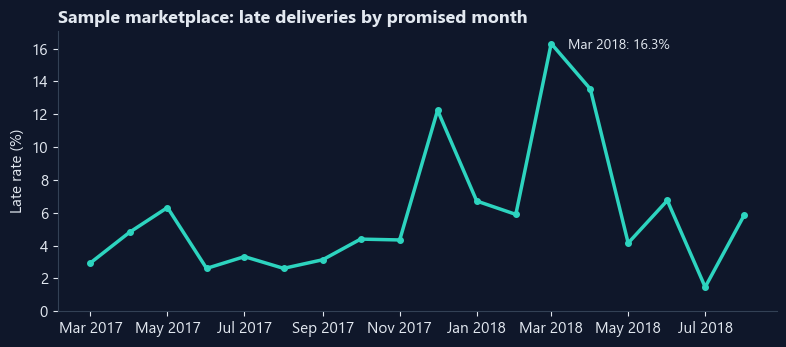

In [6]:
m = lines.groupby("due_month").agg(delivered=("delivered", "sum"), late=("late", "sum"))
m = m.loc[cfg["report"]["trend_from"][:7]:cfg["report"]["trend_to"][:7]]
m["late_rate_pct"] = 100 * m["late"] / m["delivered"]
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(m.index.to_timestamp(), m["late_rate_pct"], color=ACCENT, lw=2.5, marker="o", ms=4)
peak = m["late_rate_pct"].idxmax()
ax.annotate(f"{peak.strftime('%b %Y')}: {m.loc[peak, 'late_rate_pct']:.1f}%", (peak.to_timestamp(), m.loc[peak, "late_rate_pct"]),
            xytext=(12, -4), textcoords="offset points", color=INK, fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.set_ylabel("Late rate (%)")
ax.set_ylim(0, None)
ax.set_title(f"{NAME}: late deliveries by promised month", loc="left", fontsize=13, fontweight="bold", color=INK)
fig.tight_layout()
fig.savefig(f"{DOCS}/late-rate-by-month.png", dpi=150)
m.round(2)

## Which suppliers: the watch list
A supplier goes on the watch list when it has **at least `watch_list_min_lines` delivered lines** (enough to judge) and a
**late rate at least `watch_list_times_overall` times the rate of all suppliers**. The same rule is the `On Watch List`
measure in Power BI.

In [7]:
MIN_LINES, TIMES = RULES["watch_list_min_lines"], RULES["watch_list_times_overall"]
threshold_pct = TIMES * 100 * lines["late"].sum() / lines["delivered"].sum()

s = lines.groupby("supplier").agg(delivered=("delivered", "sum"), late=("late", "sum"))
s = s[s["delivered"] > 0]
s["late_rate_pct"] = 100 * s["late"] / s["delivered"]
s["watch"] = (s["delivered"] >= MIN_LINES) & (s["late_rate_pct"] >= threshold_pct)

watch = s[s["watch"]]
watch_share_late = round(100 * watch["late"].sum() / s["late"].sum(), 2)
watch_share_delivered = round(100 * watch["delivered"].sum() / s["delivered"].sum(), 2)
print(f"{len(s):,} suppliers delivered at least one line; {(s['late'] > 0).sum():,} were late at least once")
print(f"Watch-list late rate: {threshold_pct:.2f}% ({TIMES} x all suppliers), at least {MIN_LINES} delivered lines")
print(f"Watch list: {len(watch)} suppliers ({100 * len(watch) / len(s):.1f}% of suppliers)")
print(f"They delivered {watch_share_delivered}% of lines but {watch_share_late}% of late lines")
watch.sort_values("late", ascending=False).head(10).round(1)

2,970 suppliers delivered at least one line; 1,274 were late at least once
Watch-list late rate: 13.19% (2 x all suppliers), at least 30 delivered lines
Watch list: 61 suppliers (2.1% of suppliers)
They delivered 4.44% of lines but 12.04% of late lines


,delivered,late,late_rate_pct,watch
supplier,,,,
S0082,402,78,19.4,True
S1591,424,64,15.1,True
S1670,300,49,16.3,True
S2767,247,39,15.8,True
S0528,171,28,16.4,True
S1033,81,26,32.1,True
S2498,129,23,17.8,True
S0465,46,23,50.0,True
S2005,104,22,21.2,True


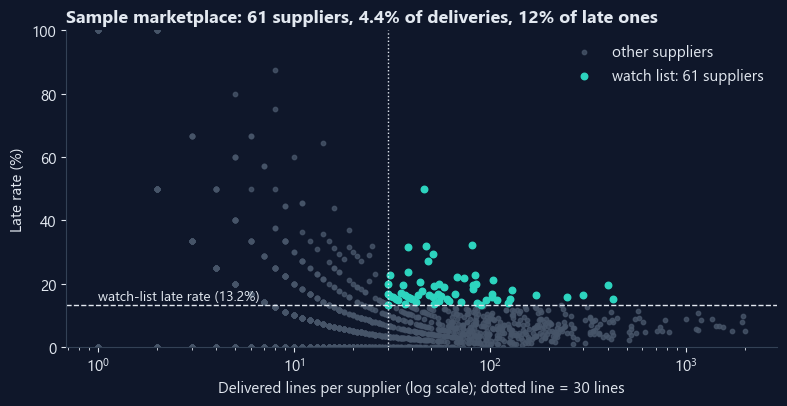

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.scatter(s.loc[~s["watch"], "delivered"], s.loc[~s["watch"], "late_rate_pct"], s=10, color=OTHER, alpha=0.8, label="other suppliers")
ax.scatter(watch["delivered"], watch["late_rate_pct"], s=22, color=ACCENT, label=f"watch list: {len(watch)} suppliers")
ax.axhline(threshold_pct, color=INK, lw=1, ls="--")
ax.axvline(MIN_LINES, color=INK, lw=1, ls=":")
ax.text(1, threshold_pct + 1.5, f"watch-list late rate ({threshold_pct:.1f}%)", fontsize=10, color=INK)
ax.set_xscale("log")
ax.set_ylim(0, 100)
ax.set_xlabel(f"Delivered lines per supplier (log scale); dotted line = {MIN_LINES} lines")
ax.set_ylabel("Late rate (%)")
ax.legend(frameon=False, loc="upper right")
ax.set_title(f"{NAME}: {len(watch)} suppliers, {watch_share_delivered:.1f}% of deliveries, {watch_share_late:.0f}% of late ones", loc="left", fontsize=13, fontweight="bold", color=INK)
fig.tight_layout()
fig.savefig(f"{DOCS}/suppliers-watch-list.png", dpi=150)

## Why late: the supplier's hand-over
Every line carries two promises: the supplier's (hand the item to the carrier by a deadline) and the customer's (delivered by a date).
When the first promise breaks, the second breaks far more often.

late_handover
On-time hand-over     5.16
Late hand-over       20.52
A late hand-over makes a late delivery 4.0 times as likely
29.02% of late deliveries started with a late hand-over by the supplier


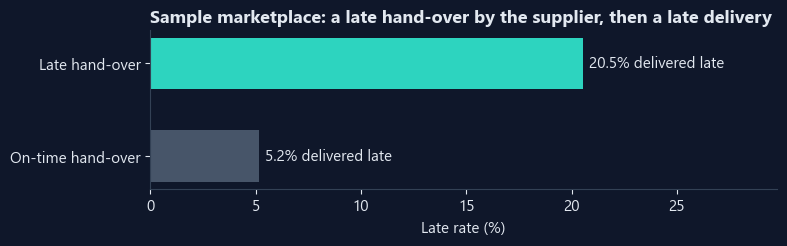

In [9]:
dl = lines[lines["delivered"] & lines["handed"]]
after = dl.groupby("late_handover")["late"].mean().mul(100).round(2)
after.index = after.index.map({False: "On-time hand-over", True: "Late hand-over"})
print(after.to_string())
if len(after) == 2:
    print(f"A late hand-over makes a late delivery {after['Late hand-over'] / after['On-time hand-over']:.1f} times as likely")
print(f"{overall['late_after_late_handover_pct']}% of late deliveries started with a late hand-over by the supplier")

fig, ax = plt.subplots(figsize=(8, 2.6))
ax.barh(after.index, after.values, color=[ACCENT if i == "Late hand-over" else OTHER for i in after.index], height=0.55)
for y, v in enumerate(after.values):
    ax.text(v + 0.3, y, f"{v:.1f}% delivered late", va="center", fontsize=11, color=INK)
ax.set_xlim(0, after.max() * 1.45)
ax.set_xlabel("Late rate (%)")
ax.set_title(f"{NAME}: a late hand-over by the supplier, then a late delivery", loc="left", fontsize=13, fontweight="bold", color=INK)
fig.tight_layout()
fig.savefig(f"{DOCS}/handover-effect.png", dpi=150)

## One order line, traced (the README's mental-model picture)
The first line, by order id, where the supplier handed over late and the customer got it late.

In [10]:
example = lines[lines["late"] & lines["late_handover"]].sort_values(["order_id", "order_item_id"]).iloc[0]
example[["order_id", "supplier", "department", "order_purchase_timestamp", "shipping_limit_date",
         "order_delivered_carrier_date", "order_estimated_delivery_date", "order_delivered_customer_date"]]

order_id                         001d8f0e34a38c37f7dba2a37d4eba8b
supplier                                                    S2962
department                                        Health & Beauty
order_purchase_timestamp                      2017-05-14 17:19:44
shipping_limit_date                           2017-05-18 17:35:11
order_delivered_carrier_date                  2017-05-24 15:45:01
order_estimated_delivery_date                 2017-05-24 00:00:00
order_delivered_customer_date                 2017-05-26 13:14:50
Name: 48, dtype: object

## The week in the summary
The week in `summary.week` and the week before it. `summarize.py` writes its summaries from these numbers.

In [11]:
WEEK = pd.Timestamp(cfg["summary"]["week"])
week = lines[lines["due_week"].isin([WEEK - pd.Timedelta(days=7), WEEK])]
week.groupby("due_week").apply(scorecard, include_groups=False)

,orders,order_lines,delivered_lines,late_lines,late_rate_pct,fill_rate_pct,otif_pct,avg_days_late,late_handover_lines,late_handover_rate_pct,late_after_late_handover_pct
due_week,,,,,,,,,,,
2018-08-20,1992.0,2262.0,2215.0,146.0,6.59,97.92,91.47,5.71,228.0,10.19,38.36
2018-08-27,1816.0,2035.0,2012.0,50.0,2.49,98.87,96.41,3.68,171.0,8.42,54.00


## The result for the website card

In [12]:
print(f"{int(overall['orders']):,} orders: {overall['late_after_late_handover_pct']:.0f}% of late deliveries started with a supplier's late hand-over, "
      f"and {len(watch)} suppliers with {watch_share_delivered:.1f}% of deliveries accounted for {watch_share_late:.0f}% of them.")

98,666 orders: 29% of late deliveries started with a supplier's late hand-over, and 61 suppliers with 4.4% of deliveries accounted for 12% of them.
